# Download the data

(1) Download the datafile called `hippocampal_neurons.npy` and `mouse_position.npy` from elearning (week 6) to your computer.

(2) Run the code cell below. It will open a file picker GUI using which you can manually select and load both `npy` datafiles by clicking `Choose Files` and navigating to the folder to which you downloaded the files. You should see the file being loaded in google colab. You're all set to move on!

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving mouse_position.npy to mouse_position.npy


In [ ]:
import numpy as np
from matplotlib import pyplot as plt
response = np.load('hippocampal_neurons.npy', allow_pickle=True)
position = np.load('mouse_position.npy')

# 1. Import

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
from scipy.ndimage import gaussian_filter1d
import umap

# 2. Inspect variable

In [ ]:
print('response shape:', response.shape)
print('position shape:', position.shape)

response shape: (36078, 188)
position shape: (36078,)


# 3. Standardize neural activity

In [ ]:
X = response.copy()
y = position.copy()
scaler = StandardScaler()
Xz = scaler.fit_transform(X)

# 4. Simple visualization

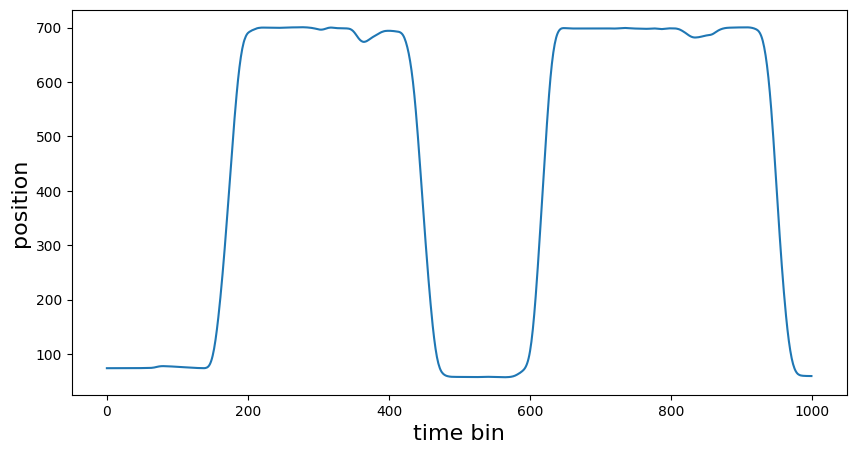

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(y[:1000])
plt.xlabel('time bin', fontsize=16)
plt.ylabel('position', fontsize=16)
plt.show()

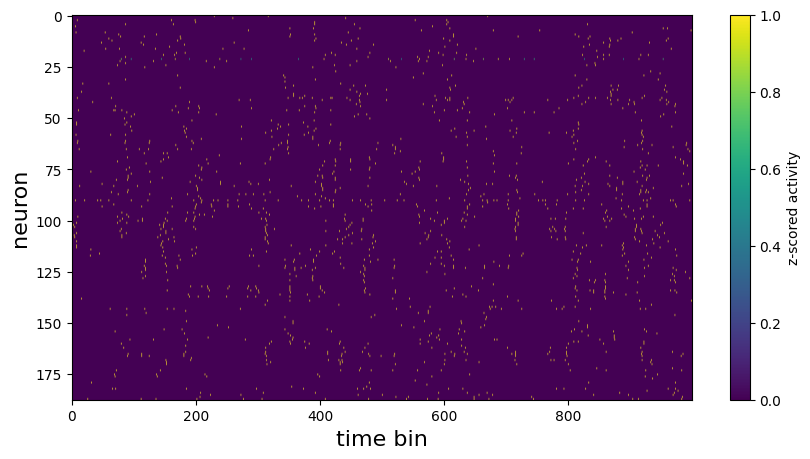

In [ ]:
plt.figure(figsize=(10, 5))
plt.imshow(Xz[:1000].T, aspect='auto', cmap='viridis', vmin=0, vmax=1)
plt.xlabel('time bin', fontsize=16)
plt.ylabel('neuron', fontsize=16)
plt.colorbar(label='z-scored activity')
plt.show()

# 5. Tuning function of neurons

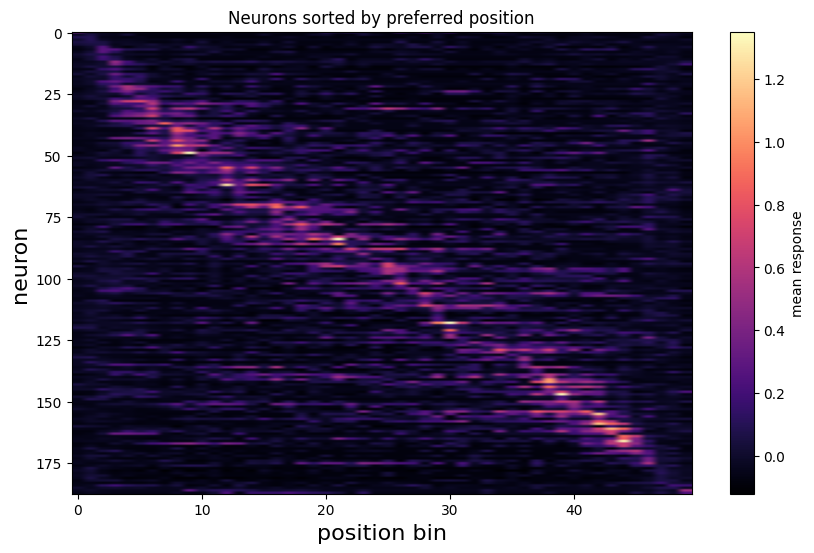

In [ ]:
n_pos_bins = 50
pos_bins = np.linspace(y.min(), y.max(), n_pos_bins + 1)
pos_bin_id = np.digitize(y, pos_bins) - 1
pos_bin_id = np.clip(pos_bin_id, 0, n_pos_bins - 1)
tuning = np.zeros((Xz.shape[1], n_pos_bins))

for neuron in range(Xz.shape[1]):
    for b in range(n_pos_bins):
        mask = pos_bin_id == b
        if mask.sum() > 0:
            tuning[neuron, b] = Xz[mask, neuron].mean()
peak_bin = np.argmax(tuning, axis=1)
order = np.argsort(peak_bin)

plt.figure(figsize=(10, 6))
plt.imshow(tuning[order], aspect='auto', cmap='magma')
plt.xlabel('position bin', fontsize=16)
plt.ylabel('neuron', fontsize=16)
plt.title('Neurons sorted by preferred position')
plt.colorbar(label='mean response')
plt.show()

## 6. PCA in neural population space

In [ ]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(Xz)
print('Fraction of variance explained:', pca.explained_variance_ratio_)

Fraction of variance explained: [0.01326101 0.01008341 0.00915776]


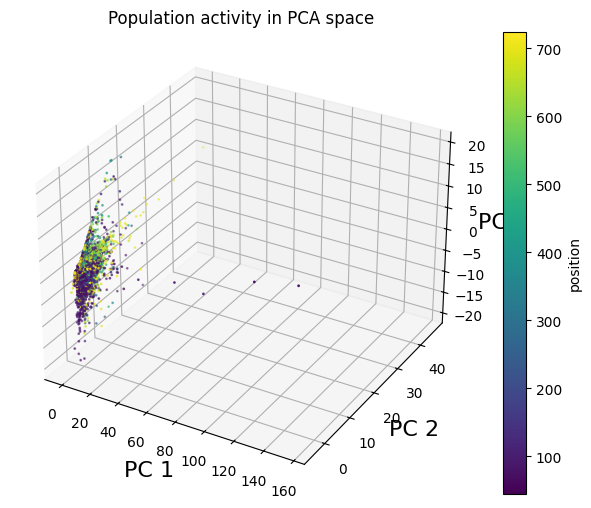

In [ ]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
pts = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=y, s=1, cmap='viridis')
ax.set_xlabel('PC 1', fontsize=16)
ax.set_ylabel('PC 2', fontsize=16)
ax.set_zlabel('PC 3', fontsize=16)
ax.set_title('Population activity in PCA space')
fig.colorbar(pts, ax=ax, label='position')
plt.show()

## 8. UMAP

A simple nonlinear dimensionality reduction technique (PCA is linear).


In [ ]:
pca = PCA(n_components=10)
X_pca = pca.fit_transform(Xz)
X_umap = umap.UMAP().fit_transform(X_pca)

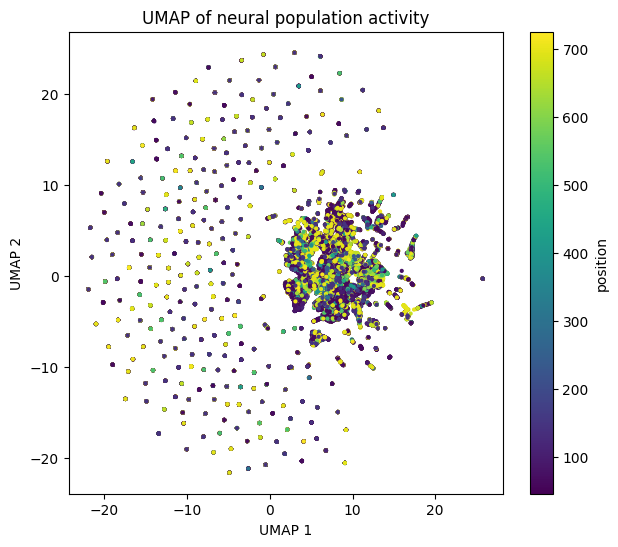

In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, s=4, cmap='viridis')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP of neural population activity')
plt.colorbar(label='position')
plt.show()

## 9. Decoding position from neural activity

We will use the first 80 percent for training and the last 20 percent for testing.

In [ ]:
from scipy.ndimage import gaussian_filter1d
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

X_use = gaussian_filter1d(Xz, sigma=2, axis=0)
y_use = y.copy()

lags = np.arange(-20, 21)
best_lag = 0
best_r2 = -np.inf
for lag in lags:
    if lag > 0:
        X_lag = X_use[:-lag]
        y_lag = y_use[lag:]
    elif lag < 0:
        X_lag = X_use[-lag:]
        y_lag = y_use[:lag]
    else:
        X_lag = X_use
        y_lag = y_use
    n = len(y_lag)
    split = int(0.8 * n)
    X_train = X_lag[:split]
    X_test = X_lag[split:]
    y_train = y_lag[:split]
    y_test = y_lag[split:]
    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    if r2 > best_r2:
        best_r2 = r2
        best_lag = lag

print('best lag:', best_lag)
print('best test R^2:', best_r2)

if best_lag > 0:
    X_final = X_use[:-best_lag]
    y_final = y_use[best_lag:]
elif best_lag < 0:
    X_final = X_use[-best_lag:]
    y_final = y_use[:best_lag]
else:
    X_final = X_use
    y_final = y_use

n = len(y_final)
split = int(0.9 * n)
X_train = X_final[:split]
X_test = X_final[split:]
y_train = y_final[:split]
y_test = y_final[split:]

model_full = Ridge(alpha=0.0)
model_full.fit(X_train, y_train)
y_pred_full = model_full.predict(X_test)
r2_full = r2_score(y_test, y_pred_full)
rmse_full = np.sqrt(mean_squared_error(y_test, y_pred_full))

print('train size:', X_train.shape[0])
print('test size:', X_test.shape[0])
print('Full population R^2:', r2_full)
print('Full population RMSE:', rmse_full)

resid = y_test - y_pred_full
resid_sd = np.std(resid)

plt.figure(figsize=(12, 4))
plt.plot(y_test[:1500], label='true position')
plt.plot(y_pred_full[:1500], label='predicted position')
plt.fill_between(np.arange(1500), y_pred_full[:1500] - resid_sd, y_pred_full[:1500] + resid_sd, alpha=0.3, label='±1 residual sd')
plt.xlabel('time index in test set')
plt.ylabel('position')
plt.title('Decoding with all neurons')
plt.legend()
plt.show()

plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred_full, s=5, alpha=0.4)
plt.xlabel('true position', fontsize=16)
plt.ylabel('predicted position', fontsize=16)
plt.title('Decoder performance')
plt.show()

NameError: name 'Xz' is not defined